In [ ]:
import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import CountVectorizer



=== WITHOUT SMOOTHING ===
Accuracy: 0.9749
Precision: 0.9485
Recall: 0.8600
F1 Score: 0.9021

=== WITH LAPLACE SMOOTHING ===
Accuracy: 0.9713
Precision: 0.8782
Recall: 0.9133
F1 Score: 0.8954


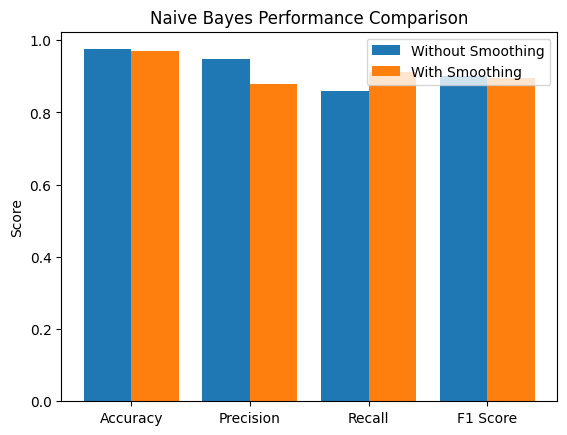

In [35]:

df = pd.read_csv("spam.csv", encoding='latin-1')
# Keep only required columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Convert labels to binary
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# =========================================
# Text Preprocessing
# =========================================

def preprocess(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    text = re.sub(r'\d+', '', text)
    return text

df['message'] = df['message'].apply(preprocess)

# =========================================
# Bag of Words
# =========================================

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['message']).toarray()
y = df['label'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# Naive Bayes Class
# =========================================

class NaiveBayes:
    def __init__(self, laplace=0):
        self.laplace = laplace

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.vocab_size = X.shape[1]

        self.priors = {}
        self.word_probs = {}

        for c in self.classes:
            X_c = X[y == c]
            self.priors[c] = X_c.shape[0] / X.shape[0]

            word_count = np.sum(X_c, axis=0)
            total_words = np.sum(word_count)

            # Apply Laplace smoothing
            self.word_probs[c] = (word_count + self.laplace) / \
                                 (total_words + self.laplace * self.vocab_size)

    def predict(self, X):
        predictions = []

        for x in X:
            class_probs = {}

            for c in self.classes:
                log_prob = np.log(self.priors[c])

                probs = self.word_probs[c]

                # Avoid log(0)
                probs = np.where(probs == 0, 1e-10, probs)

                log_prob += np.sum(x * np.log(probs))
                class_probs[c] = log_prob

            predictions.append(max(class_probs, key=class_probs.get))

        return np.array(predictions)

# =========================================
# Evaluation Function
# =========================================

def evaluate(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

# =========================================
# Task 2: Without Smoothing
# =========================================

nb_no = NaiveBayes(laplace=0)
nb_no.fit(X_train, y_train)
y_pred_no = nb_no.predict(X_test)

results_no = evaluate(y_test, y_pred_no)

print("\n=== WITHOUT SMOOTHING ===")
for k, v in results_no.items():
    print(f"{k}: {v:.4f}")

# =========================================
# Task 3 & 4: With Laplace Smoothing
# =========================================

nb_s = NaiveBayes(laplace=1)
nb_s.fit(X_train, y_train)
y_pred_s = nb_s.predict(X_test)

results_s = evaluate(y_test, y_pred_s)

print("\n=== WITH LAPLACE SMOOTHING ===")
for k, v in results_s.items():
    print(f"{k}: {v:.4f}")

# =========================================
# Task 5: Comparison Graph
# =========================================

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

no_vals = [results_no[m] for m in metrics]
s_vals = [results_s[m] for m in metrics]

x = np.arange(len(metrics))

plt.figure()
plt.bar(x - 0.2, no_vals, width=0.4, label='Without Smoothing')
plt.bar(x + 0.2, s_vals, width=0.4, label='With Smoothing')

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Naive Bayes Performance Comparison")
plt.legend()

plt.show()